In [1]:
# Install missing packages
%pip install --quiet networkx

#P1 Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer

import networkx as nx

import joblib

/Users/atifansari/Documents/GitHub/Semiconductor-Supply-Chain-Risk-Prediction-System/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

/Users/atifansari/Documents/GitHub/Semiconductor-Supply-Chain-Risk-Prediction-System/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv(
    "from_V1_supply_chain_data.csv"
)

df.head()

,year,reporter,reporter_code,partner,partner_code,flow,flow_code,hs_code,commodity,trade_value_usd,net_weight_kg,lag_trade_1y,yoy_growth_pct,rolling_avg_3y,volatility_index,total_imports,supplier_dependency_ratio,sudden_drop_flag,future_trade_value_usd
0,2019,China,156,Germany,276,Export,X,854231,Electronic integrated circuits; processors and...,4.304729e+08,381167.000,406279543.0,5.954852,4.183762e+08,1.710728e+07,3.070908e+10,0.014018,0,4.701358e+08
1,2020,China,156,Germany,276,Export,X,854231,Electronic integrated circuits; processors and...,4.701358e+08,437967.353,430472888.0,9.213808,4.356294e+08,3.223893e+07,3.241534e+10,0.014503,0,6.056375e+08
2,2021,China,156,Germany,276,Export,X,854231,Electronic integrated circuits; processors and...,6.056375e+08,586254.000,470135833.0,28.821814,5.020821e+08,9.184815e+07,4.199449e+10,0.014422,0,8.155781e+08
3,2022,China,156,Germany,276,Export,X,854231,Electronic integrated circuits; processors and...,8.155781e+08,683406.339,605637510.0,34.664394,6.304505e+08,1.740527e+08,4.360048e+10,0.018706,0,1.154173e+09
4,2023,China,156,Germany,276,Export,X,854231,Electronic integrated circuits; processors and...,1.154173e+09,868952.000,815578081.0,41.515899,8.584627e+08,2.767707e+08,3.585819e+10,0.032187,0,9.870469e+08


In [4]:
#P3 Dataset Inspection
df.info()
df.describe()  

<class 'pandas.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       1260 non-null   int64  
 1   reporter                   1260 non-null   str    
 2   reporter_code              1260 non-null   int64  
 3   partner                    1260 non-null   str    
 4   partner_code               1260 non-null   int64  
 5   flow                       1260 non-null   str    
 6   flow_code                  1260 non-null   str    
 7   hs_code                    1260 non-null   int64  
 8   commodity                  1260 non-null   str    
 9   trade_value_usd            1260 non-null   float64
 10  net_weight_kg              1260 non-null   float64
 11  lag_trade_1y               1260 non-null   float64
 12  yoy_growth_pct             1260 non-null   float64
 13  rolling_avg_3y             1260 non-null   float64
 14  vol

,year,reporter_code,partner_code,hs_code,trade_value_usd,net_weight_kg,lag_trade_1y,yoy_growth_pct,rolling_avg_3y,volatility_index,total_imports,supplier_dependency_ratio,sudden_drop_flag,future_trade_value_usd
count,1260.000000,1260.000000,1260.000000,1260.000000,1.260000e+03,1.260000e+03,1.260000e+03,1260.000000,1.260000e+03,1.260000e+03,1.260000e+03,1260.000000,1260.000000,1.260000e+03
mean,2021.000000,472.285714,472.285714,854234.000000,1.270209e+09,2.237750e+05,1.273123e+09,20.399009,1.249880e+09,2.464266e+08,8.679804e+09,0.189020,0.247619,1.323904e+09
std,1.414775,220.946870,220.946870,3.560439,4.052154e+09,5.046815e+05,4.367514e+09,178.271565,4.192301e+09,8.671366e+08,1.351834e+10,0.381222,0.431801,4.167149e+09
min,2019.000000,156.000000,156.000000,854231.000000,2.311866e+04,0.000000e+00,2.311866e+04,-99.513684,7.326329e+04,1.420401e+04,1.365098e+08,0.000010,0.000000,6.682216e+04
25%,2020.000000,276.000000,276.000000,854231.000000,5.763512e+07,3.373448e+03,5.965798e+07,-19.935550,5.892865e+07,1.135909e+07,1.594946e+09,0.021707,0.000000,5.093171e+07
50%,2021.000000,410.000000,410.000000,854232.000000,2.515862e+08,3.480905e+04,2.515862e+08,0.745639,2.595913e+08,4.769766e+07,2.812422e+09,0.079201,0.000000,2.546504e+08
75%,2022.000000,702.000000,702.000000,854239.000000,7.892916e+08,1.920282e+05,7.848579e+08,28.856209,7.874705e+08,1.628585e+08,9.904558e+09,0.230596,0.000000,8.074529e+08
max,2023.000000,842.000000,842.000000,854239.000000,5.499935e+10,6.157041e+06,6.372054e+10,5302.694425,5.406656e+10,1.365279e+10,6.670568e+10,5.876191,1.000000,5.499935e+10


In [5]:
df.shape

(1260, 19)

In [6]:
df.isnull().sum()

year                         0
reporter                     0
reporter_code                0
partner                      0
partner_code                 0
flow                         0
flow_code                    0
hs_code                      0
commodity                    0
trade_value_usd              0
net_weight_kg                0
lag_trade_1y                 0
yoy_growth_pct               0
rolling_avg_3y               0
volatility_index             0
total_imports                0
supplier_dependency_ratio    0
sudden_drop_flag             0
future_trade_value_usd       0
dtype: int64

In [7]:
#P4 Create Disruption Label
df["disruption_label"] = (
    df["yoy_growth_pct"] < -20
).astype(int)

In [8]:
#P5 Additional V2 Feature Engineering
#5.1 Export Concentration Ratio

# The V1 CSV uses singular flow labels: Import / Export.
total_exports = (
    df[df["flow"].eq("Export")]
    .groupby(
        [
            "year",
            "reporter",
            "hs_code"
        ]
    )["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "trade_value_usd": "total_exports"
        }
    )
)

total_exports.head()


,year,reporter,hs_code,total_exports
0,2019,China,854231,4.466637e+09
1,2019,China,854232,1.683464e+10
2,2019,China,854239,1.387601e+09
3,2019,Germany,854231,2.285239e+09
4,2019,Germany,854232,1.779324e+08


In [9]:
#step 2 - merge exports
# Drop previous merge outputs so this cell can be rerun safely.
df = df.drop(
    columns=[
        col for col in [
            "total_exports",
            "total_exports_x",
            "total_exports_y",
            "export_concentration_ratio",
        ]
        if col in df.columns
    ]
)

df = df.merge(
    total_exports,
    on=[
        "year",
        "reporter",
        "hs_code"
    ],
    how="left"
)

df[["year", "reporter", "hs_code", "flow", "total_exports"]].head()


,year,reporter,hs_code,flow,total_exports
0,2019,China,854231,Export,4.466637e+09
1,2020,China,854231,Export,4.593175e+09
2,2021,China,854231,Export,5.460937e+09
3,2022,China,854231,Export,7.741137e+09
4,2023,China,854231,Export,7.975838e+09


In [10]:
#step 3 - concentration ratio
# Avoid divide-by-zero or missing export totals.
# If this cell is run by itself, rebuild total_exports first.
if "total_exports" not in df.columns:
    total_exports = (
        df[df["flow"].eq("Export")]
        .groupby(["year", "reporter", "hs_code"])["trade_value_usd"]
        .sum()
        .reset_index()
        .rename(columns={"trade_value_usd": "total_exports"})
    )

    df = df.drop(
        columns=[
            col for col in ["total_exports_x", "total_exports_y"]
            if col in df.columns
        ]
    )
    df = df.merge(
        total_exports,
        on=["year", "reporter", "hs_code"],
        how="left"
    )

df["export_concentration_ratio"] = np.where(
    df["total_exports"].gt(0),
    df["trade_value_usd"] / df["total_exports"],
    np.nan
)

df[["flow", "trade_value_usd", "total_exports", "export_concentration_ratio"]].head()


,flow,trade_value_usd,total_exports,export_concentration_ratio
0,Export,4.304729e+08,4.466637e+09,0.096375
1,Export,4.701358e+08,4.593175e+09,0.102355
2,Export,6.056375e+08,5.460937e+09,0.110904
3,Export,8.155781e+08,7.741137e+09,0.105356
4,Export,1.154173e+09,7.975838e+09,0.144709


In [11]:
#P6 Alternative Supplier Count
# to measure supply-chain resilience
supplier_counts = (
    df.groupby(
        [
            "year",
            "reporter",
            "hs_code"
        ]
    )["partner"]
    .nunique()
    .reset_index()
    .rename(
        columns={
            "partner":
            "alternative_supplier_count"
        }
    )
)

In [12]:
# Merge supplier counts
# Drop previous merge outputs so this cell can be rerun safely.
df = df.drop(
    columns=[
        col for col in [
            "alternative_supplier_count",
            "alternative_supplier_count_x",
            "alternative_supplier_count_y",
        ]
        if col in df.columns
    ]
)

df = df.merge(
    supplier_counts,
    on=[
        "year",
        "reporter",
        "hs_code"
    ],
    how="left"
)

df[["year", "reporter", "hs_code", "alternative_supplier_count"]].head()


,year,reporter,hs_code,alternative_supplier_count
0,2019,China,854231,6
1,2020,China,854231,6
2,2021,China,854231,6
3,2022,China,854231,6
4,2023,China,854231,6


In [13]:
#P7 Network Analysis

G = nx.from_pandas_edgelist(
    df,
    source="reporter",
    target="partner",
    edge_attr="trade_value_usd",
    create_using=nx.DiGraph()
)

In [14]:
#7.1 Degree Centality
centrality = nx.degree_centrality(G)

df["network_centrality"] = (
    df["reporter"]
    .map(centrality)
)

In [15]:
#7.2 Betweeness Centrality
#Bottleneck risk
betweenness = nx.betweenness_centrality(G)

df["bottleneck_score"] = (
    df["reporter"]
    .map(betweenness)
)

In [16]:
#8 Handling Missing Features
numeric_cols = list(
    df.select_dtypes(
        include=np.number
    ).columns
)

imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True
)

df[numeric_cols] = pd.DataFrame(
    imputer.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

print("Missing numeric values after imputation:", int(df[numeric_cols].isnull().sum().sum()))
df[numeric_cols].head()


Missing numeric values after imputation: 0


,year,reporter_code,partner_code,hs_code,trade_value_usd,net_weight_kg,lag_trade_1y,yoy_growth_pct,rolling_avg_3y,volatility_index,total_imports,supplier_dependency_ratio,sudden_drop_flag,future_trade_value_usd,disruption_label,total_exports,export_concentration_ratio,alternative_supplier_count,network_centrality,bottleneck_score
0,2019.0,156.0,276.0,854231.0,4.304729e+08,381167.000,406279543.0,5.954852,4.183762e+08,1.710728e+07,3.070908e+10,0.014018,0.0,4.701358e+08,0.0,4.466637e+09,0.096375,6.0,2.0,0.0
1,2020.0,156.0,276.0,854231.0,4.701358e+08,437967.353,430472888.0,9.213808,4.356294e+08,3.223893e+07,3.241534e+10,0.014503,0.0,6.056375e+08,0.0,4.593175e+09,0.102355,6.0,2.0,0.0
2,2021.0,156.0,276.0,854231.0,6.056375e+08,586254.000,470135833.0,28.821814,5.020821e+08,9.184815e+07,4.199449e+10,0.014422,0.0,8.155781e+08,0.0,5.460937e+09,0.110904,6.0,2.0,0.0
3,2022.0,156.0,276.0,854231.0,8.155781e+08,683406.339,605637510.0,34.664394,6.304505e+08,1.740527e+08,4.360048e+10,0.018706,0.0,1.154173e+09,0.0,7.741137e+09,0.105356,6.0,2.0,0.0
4,2023.0,156.0,276.0,854231.0,1.154173e+09,868952.000,815578081.0,41.515899,8.584627e+08,2.767707e+08,3.585819e+10,0.032187,0.0,9.870469e+08,0.0,7.975838e+09,0.144709,6.0,2.0,0.0


In [31]:
#P9 Selecting Features for V2
features = [

    "trade_value_usd",

    "net_weight_kg",

    "lag_trade_1y",

    #"yoy_growth_pct",

    "rolling_avg_3y",

    "volatility_index",

    "supplier_dependency_ratio",

    "export_concentration_ratio",

    "alternative_supplier_count",

    "network_centrality",

    "bottleneck_score"
]

In [32]:
target = "disruption_label"

In [33]:
#P10 Prepare Dataset
X = df[features]

y = df[target]

In [34]:
#P11 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #we use stratify here because disruption is a rare event
)

In [35]:
#P12 Model Training
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [36]:
#P13 Model Prediction
y_pred = model.predict(X_test)

In [37]:
#P14 Model Evaluation
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8293650793650794


In [38]:
#Precision
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8518518518518519


In [39]:
#Recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.3709677419354839


In [40]:
#F1 Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.5168539325842697


In [41]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.83      0.98      0.90       190
         1.0       0.85      0.37      0.52        62

    accuracy                           0.83       252
   macro avg       0.84      0.67      0.71       252
weighted avg       0.83      0.83      0.80       252



In [42]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[186   4]
 [ 39  23]]


In [43]:
#P16 checking Feature Importance
importance_df = pd.DataFrame({

    "Feature": features,

    "Importance":
        model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                      Feature  Importance
0             trade_value_usd    0.263813
2                lag_trade_1y    0.196140
4            volatility_index    0.159771
3              rolling_avg_3y    0.116897
6  export_concentration_ratio    0.102551
5   supplier_dependency_ratio    0.088441
1               net_weight_kg    0.072387
7  alternative_supplier_count    0.000000
8          network_centrality    0.000000
9            bottleneck_score    0.000000


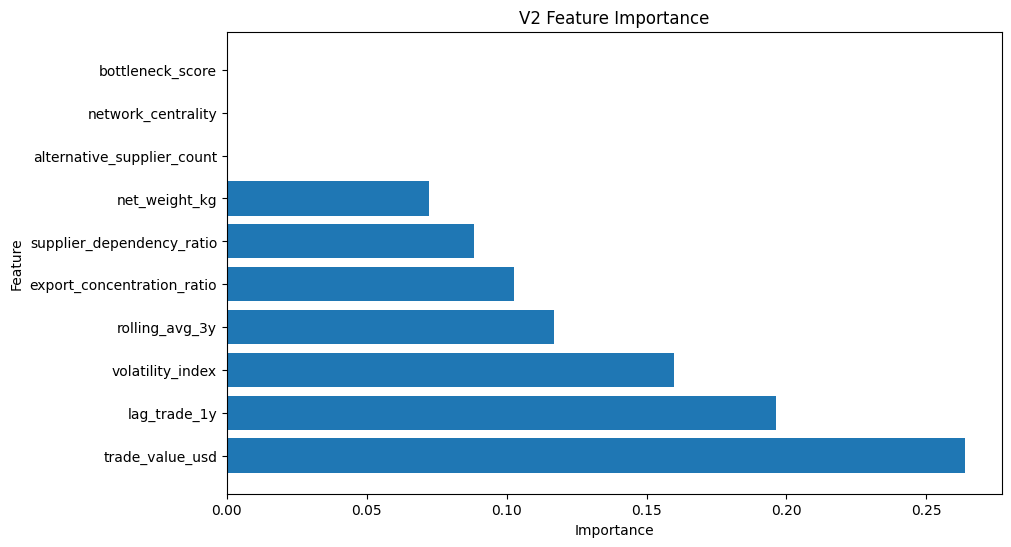

In [44]:
#Visualisation
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("V2 Feature Importance")

plt.show()